In [1]:
import numpy as np
import matplotlib.pyplot as plt


## Task 1
2 SAT generator and 1in2 SAT are the same
The generic SAT problem here is a (m x n) array. We will specify the nature of the problem later

In [72]:
def generator(n, m, seed=42):
    np.random.seed(seed)
    clauses = []
    max_num_clauses = n * (n - 1) * 2
    while len(clauses) < m and len(clauses) < max_num_clauses:
        a = np.random.randint(1, n + 1)
        interval = np.concatenate((np.arange(1, a), np.arange(a + 1, n + 1))) # Exclude 'a' since it cannot be the same variable in the same clause
        b = int(np.random.choice(interval))
        sign_a = np.random.choice([True, False])
        sign_b = np.random.choice([True, False])
        new_clause = (a if sign_a else -a, b if sign_b else -b)
        new_clause = tuple(sorted(new_clause, key=lambda x: abs(x))) # Sort by absolute value to avoid duplicates like (1, -2) and (-2, 1)
        for old_clause in clauses:
            if old_clause == new_clause:
                break
        else:
            clauses.append(new_clause)
    return clauses

problem = generator(5, 8, seed=2)
print(problem)
print(len(problem))

[(-1, 5), (3, -4), (-2, -3), (1, 3), (3, 4), (-4, 5), (2, 3), (2, 4)]
8


Total number of clauses without repetitions: $$ C = \binom{n}{k} 2^k $$

In [73]:
def num_violated(bitstring, SATproblem, one_in_two = False):
    violated_count = 0
    if one_in_two is False:
        for clause in SATproblem:
            var1, var2 = abs(clause[0]), abs(clause[1])
            assignment = [bitstring[var1-1], bitstring[var2-1]]
            if clause[0] < 0: assignment[0] = 1 if assignment[0] == 0 else 0
            if clause[1] < 0: assignment[1] = 1 if assignment[1] == 0 else 0
            res = sum(assignment)
            if res == 0: violated_count += 1
    return violated_count

bitstring = [0,0,0,1,0]
print(num_violated(bitstring, SATproblem=problem))

4


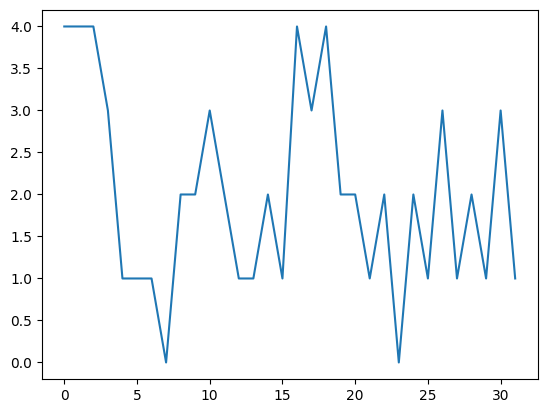

In [74]:
def brute_force(n, SATproblem, one_in_two = False):
    bitstrings_dec = []
    cost = []
    for x in range(0,2**n):
        bitstring = [int(bit) for bit in f"{x:0{n}b}"]
        bitstrings_dec.append(x)
        cost.append(num_violated(bitstring, SATproblem, one_in_two))
    return bitstrings_dec, cost

example = brute_force(5, problem)

plt.plot(example[0], example[1]);

Il numero totale di formule $k$-SAT è:$$ \binom{C}{m} = \binom{\binom{n}{k} 2^k}{m} $$
Se m è saturato, allora il numero di clausole violate è costante per qualsiasi assignment ed è pari a $$ \binom{C}{m} $$